In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

In [62]:
df = sns.load_dataset('penguins')

In [63]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [64]:
df.tail()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female
343,Gentoo,Biscoe,49.9,16.1,213.0,5400.0,Male


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [66]:
df.isnull().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


In [67]:
df.dropna(inplace=True)

In [68]:
df.isnull().sum()

,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


In [97]:
# Convert float columns to int64
float_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
for col in float_cols:
    df[col] = df[col].astype('int64')

# Display DataFrame info to verify data types
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   species            333 non-null    int64
 1   island             333 non-null    int64
 2   bill_length_mm     333 non-null    int64
 3   bill_depth_mm      333 non-null    int64
 4   flipper_length_mm  333 non-null    int64
 5   body_mass_g        333 non-null    int64
 6   sex                333 non-null    int64
dtypes: int64(7)
memory usage: 28.9 KB


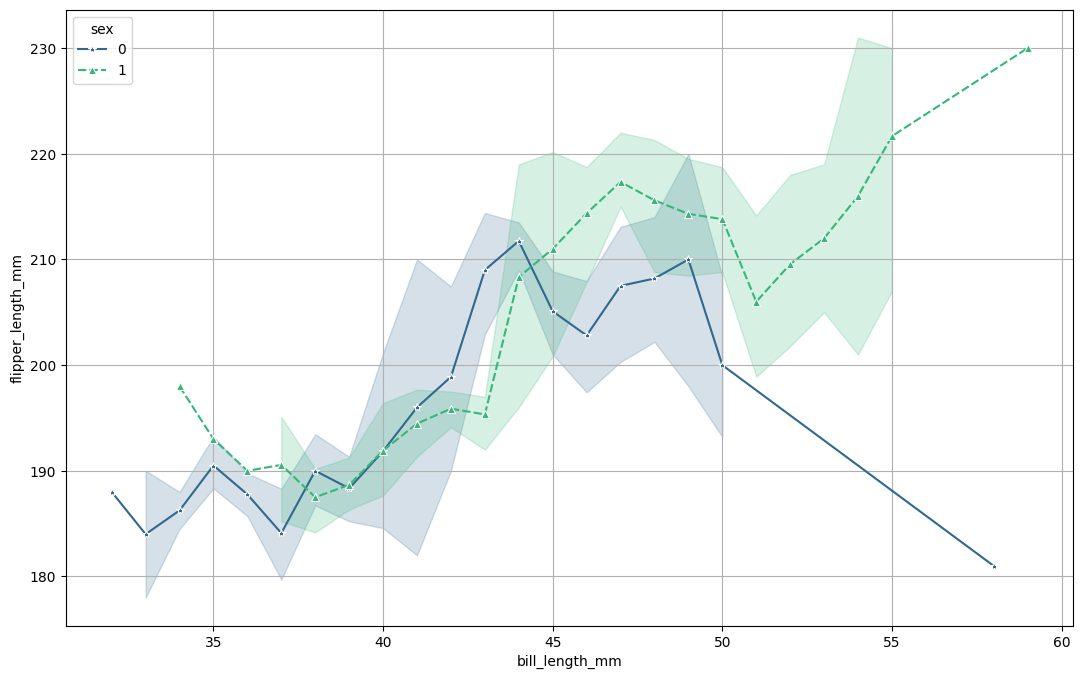

In [98]:
plt.figure(figsize=[13,8])
sns.lineplot(x='bill_length_mm', y ='flipper_length_mm', data=df, hue='sex', palette='viridis', markers=["*","^"], style='sex')
plt.grid()
plt.show()

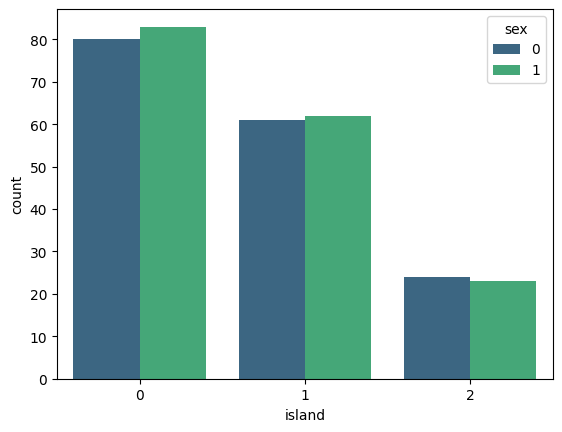

In [99]:
sns.countplot(x='island',data=df, palette='viridis', hue='sex')
plt.show()

/tmp/ipykernel_899/3213325949.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='species',data=df, palette='viridis')


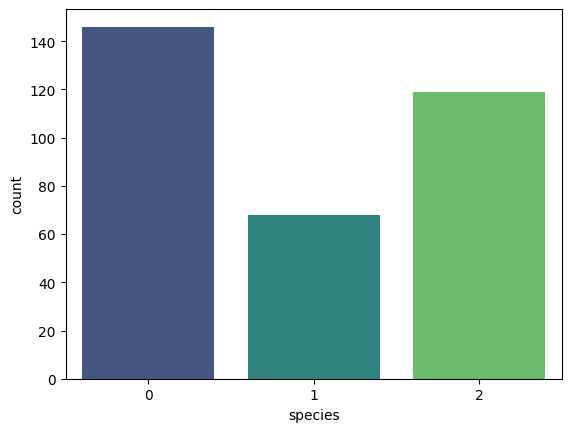

In [100]:
sns.countplot(x='species',data=df, palette='viridis')
plt.show()

In [101]:
df.describe()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
count,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000
mean,0.918919,0.651652,43.561562,16.735736,200.966967,4207.057057,0.504505
std,0.889718,0.714715,5.478872,1.986964,14.015765,805.215802,0.500732
min,0.000000,0.000000,32.000000,13.000000,172.000000,2700.000000,0.000000
25%,0.000000,0.000000,39.000000,15.000000,190.000000,3550.000000,0.000000
50%,1.000000,1.000000,44.000000,17.000000,197.000000,4050.000000,1.000000
75%,2.000000,1.000000,48.000000,18.000000,213.000000,4775.000000,1.000000
max,2.000000,2.000000,59.000000,21.000000,231.000000,6300.000000,1.000000


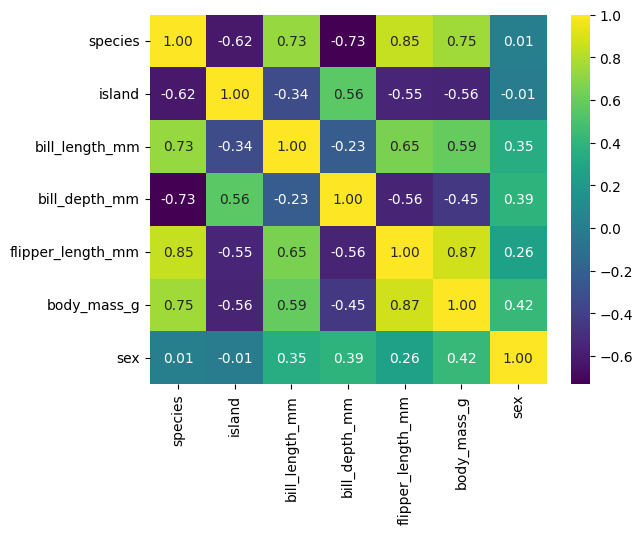

In [102]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt=".2f")
plt.show()

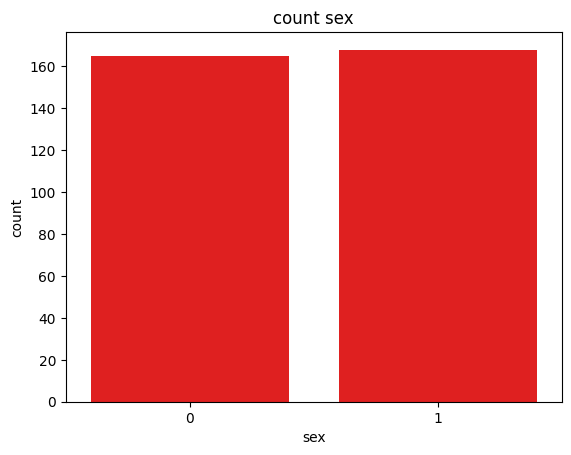

In [103]:
sns.countplot(x='sex',data=df,color='red')
plt.title('count sex')
plt.show()

In [106]:
X = df.drop(columns='sex',axis=1)
y = df['sex']

In [107]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [108]:
encoder = LabelEncoder()

In [109]:
df['island'] = encoder.fit_transform(df['island'])
df['species'] = encoder.fit_transform(df['species'])
df['sex'] = encoder.fit_transform(df['sex'])

In [110]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,0,2,39,18,181,3750,1
1,0,2,39,17,186,3800,0
2,0,2,40,18,195,3250,0
4,0,2,36,19,193,3450,0
5,0,2,39,20,190,3650,1


In [111]:
df.tail()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
338,2,0,47,13,214,4925,0
340,2,0,46,14,215,4850,0
341,2,0,50,15,222,5750,1
342,2,0,45,14,212,5200,0
343,2,0,49,16,213,5400,1


In [112]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [113]:
X_train.shape

(266, 6)

In [114]:
X_test.shape

(67, 6)

In [115]:
y_train.shape

(266,)

In [116]:
y_test.shape

(67,)

In [117]:
from sklearn.linear_model import LogisticRegression

In [118]:
lr = LogisticRegression()

In [119]:
lr.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [120]:
y_pred = lr.predict(X_test)

In [140]:
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, f1_score

In [132]:
acc = accuracy_score(y_test,y_pred)

In [133]:
print(f'Your accuracy is {acc * 100:.2f}%')

Your accuracy is 88.06%


In [143]:
r_score = recall_score(y_test,y_pred)
print(f'Your recall_score is {r_score * 100:.2f}%')

Your recall_score is 90.00%


In [139]:
metrics = confusion_matrix(y_test,y_pred)
print(f'{metrics}')

[[32  5]
 [ 3 27]]


In [141]:
f_score = f1_score(y_test,y_pred)
print(f_score)

0.8709677419354839
